Przed oddaniem zadania upewnij się, że wszystko działa poprawnie.
**Uruchom ponownie kernel** (z paska menu: Kernel$\rightarrow$Restart) a następnie
**wykonaj wszystkie komórki** (z paska menu: Cell$\rightarrow$Run All).

Upewnij się, że wypełniłeś wszystkie pola `TU WPISZ KOD` lub `TU WPISZ ODPOWIEDŹ`, oraz
że podałeś swoje imię i nazwisko poniżej:

In [1]:
NAME = "Izabela Paniczek"

---

# 2. Model TNC

Przedstawimy teraz zasadę działania modelu TNC, zaimplementujemy jego  najistotniejsze elementy oraz dokonamy ewaluacji modelu.

## 2.1. Idea modelu TNC
Dla ciągu czasowego $X \in \mathbb{R}^{D \times T}$ możemy określić okno przesuwne $X_{[t - \frac{\delta}{2}, t + \frac{\delta}{2}]}$ o długości $\delta$ wycentrowane wokół chwili $t$, które zawiera pomiary wszystkich cech w przedziale czasu $[t - \frac{\delta}{2}, t + \frac{\delta}{2}]$. Dla ułatwienia zapisu okno to będzie oznaczane jako $W_t$.

Celem metody uczenia reprezentacji będzie uzyskanie wektorowej reprezentacji dowolnego okna $W_t$.

### Temporalne sąsiedztwo
Dla okna $W_t$ zdefiniujmy jego temporalne sąsiedztwo $N_t$ jako zbiór wszystkich okien wycentrowanych w $t^*$, gdzie wartość ta jest próbkowana z rozkładu normalnego $t^* \sim \mathcal{N}(t, \eta \cdot \delta)$. Parametr $\eta$ definiuje szerokość / zakres sąsiedztwa temporalnego.

Wybór parametru $\eta$ może być oparty o wiedzę ekspercką, jednak w publikacji autorzy zaproponowali zastosowanie testu statystycznego **Augmented Dickey-Fuller (ADF)**, który będzie sprawdzać stacjonarność rozkładu próbek w sąsiedztwie temporalnym. Algorytm wyboru parametru zakłada, że rozpoczynamy od niewielkiej wartości, po czym iteracyjnie zwiększamy parametr $\eta$, powodując poszerzenie się temporalnego sąsiedztwa. Zwiększanie wartości następuje do momentu aż test statystyczny nie będzie w stanie odrzucić hipotezy zerowej.


### "Uczenie kontrastowe"
Okna w sąsiedztwie temporalnym możemy uznać jako podobne do obecnie rozważanego okna ciągu czasowego. Pozostaje zatem pytanie jak uzyskać przykłady negatywne, tak abyśmy mogli zastosować koncepcję uczenia kontrastowego. 

Moglibyśmy założyć, że wszystkie próbki (okna) poza temporalnym sąsiedztwem są przykładami negatywnymi. Może się jednak tak zdarzyć, że nawet bardzo odległe okno, jest w istocie podobne do obecnego (ma taką samą dynamikę zmian / pochodzi z tego samego rozkładu). W takiej sytuacji uczenie modelu nie byłoby efektywne. Autorzy proponują użycie podejścia **Positive-Unlabeled (PU) learning**, w którym mamy próbki bazowe, próbki pozytywne i próbki nieoznaczone. W naszym przykładzie próbkami nieoznaczonymi będą próbki spoza sąsiedztwa temporalnego.

Do próbek nieoznaczonych są przypisywane wagi $w$ (tutaj: hiperparametr metody), a każda próbka nieoznaczona jest traktowana jako połączenie próbki pozytywnej z wagą $w$ oraz próbki negatywnej z wagą $1 - w$. Zobaczymy to dalej w funkcji kosztu.

### Koder i dyskryminator
Model TNC będziemy uczyć za pomocą funkcji kosztu, która pozwala odróżniać reprezentacje próbek z tego samego sąsiedztwa temporalnego od próbek spoza sąsiedztwa.

Pierwszym elementem modelu TNC jest **koder** $\text{Enc}(W_t)$, które przekształca okno $W_t \in \mathbb{R}^{D \times \delta}$ w wektor reprezentacji $Z_t \in \mathbb{R}^M$.

Drugim elementem jest **dyskryminator** $\mathcal{D}(Z_t, Z)$ pozwalający aproksymować prawdopodobieństwo tego, że $Z$ jest reprezentacją okna w sąsiedztwie $N_t$. Innymi słowy, dla dwóch wektorów reprezentacji zwraca prawdopodobieństwo tego, że te wektory (okna) należą do tego samego sąsiedztwa temporalnego.

Przeanalizujmy rysunek przedstawiający zasadę działania modelu TNC:

![](./assets/tnc.png)

### Funkcja kosztu
W najlepszym przypadku dyskryminator powinien zwracać wartości bliskie 1 dla reprezentacji z tego samego temporalnego sąsiedztwa oraz wartość 0 w przeciwnym przypadku. Funkcja kosztu jest zdefiniowana następująco:

$$\mathcal{L} = -\mathbb{E}_{W_t\sim X}\left[ \mathbb{E}_{W_l \sim N_t}[\log \mathcal{D}(Z_t,Z_l)] +\mathbb{E}_{W_k \sim \bar{N}_t}[(1-w_t)\times \log(1 - \mathcal{D}(Z_t, Z_k)) + w_t\times \log\mathcal{D}(Z_t, Z_k)] \right]$$

## 2.2. Implementacja kodera
Ze względu na sekwencyjny charakter próbek w oknie, jako model kodera użyjemy dwukierunkowej sieci rekurencyjnego typu GRU, która na wyjściu cechy przekształci dodatkową warstwą liniową. Sieć rekurencyjna dostarcza nam stany ukryte w formie wektorów dla każdego punktu wejściowego w sekwencji, więc w celu otrzymania jednego wektora podsumowującego całą sekwencję należy dokonać odpowiedniej agregacji. W niniejszym koderze rozwarzymy dwie metody agregacji sekwencji stanów ukrytych:
* wybór ostatniego stanu ukrytego
* agregacja stanów ukrytych z wykorzystaniem mechanizmu uwagi (ang. _attention_) 

## Zadanie 2.1 (1.5 pkt)
Zaimplementuj dwie klasy dla dwóch niżej zdefiniowanych stanów ukrytych:

1. `LastHiddenAggreagation` (0.5 pkt) - metoda `forward(...)` zwraca ostatni stan ukryty z sekwencji (pamiętaj, że jest to sieć dwukierunkowa, więc ostatnie stany ukryte dla każdego z kierunku będą na przeciwnych końcach hidden states)
2. `AttentionAggregation` (1 pkt):
      * aplikuje [*scaled dot product attention*](https://arxiv.org/abs/1706.03762) oraz oblicza średnią z otrzymanych wektorów
      * podpowiedź: możesz wykorzystać `torch.nn.MultiHeadAttention` z parametrem `num_heads=1`, ale **należy mieć zrozumienie i intuicje, jak działa mechanizm uwagi i jak może pomagać w agregacji**

In [4]:
import torch
from torch import nn, Tensor
import torch.nn.functional as F

class LastHiddenAggregation(nn.Module):
    def forward(self, rnn_output: Tensor) -> Tensor:
        """Aggregates information from sequence of vectors by taking last state.
        rnn_output: Tensor with dimensions [sequence_length, batch_size, hidden_dim]
        returns: Tensor with dimensions [batch_size, hidden_dim]
        """
        # TU WPISZ KOD
        hidden_size = rnn_output.shape[-1] // 2

        forward_last = rnn_output[-1, :, :hidden_size]
        backward_last = rnn_output[0, :, hidden_size:]
        return torch.cat((forward_last, backward_last), dim=1)

class AttentionAggregation(nn.Module):
    def __init__(self, hidden_dim: int):
        super().__init__()
        # TU WPISZ KOD
        self.attention = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=1, batch_first=False)

    def forward(self, rnn_output: Tensor) -> Tensor:
        """Aggregates information from sequence of vectors with scaled-dot-product attention.
        rnn_output: Tensor with dimensions [sequence_length, batch_size, hidden_dim]
        returns: Tensor with dimensions [batch_size, hidden_dim]
        """
        # TU WPISZ KOD
        # rnn_output to [seq_len, batch_size, hidden_dim]
        # Q = K = V = rnn_output
        # Dla każdego elementu sekwencji liczona jest uwaga do wszystkich pozostałych
        # Attention(Q,K,V) = softmax(QK^T / sqrt(d_k)) V
        attn_output, _ = self.attention(
            rnn_output,  # query
            rnn_output,  # key
            rnn_output   # value
        )

        return attn_output.mean(dim=0)

## Zadanie 2.2 (1.5 pkt)
Zaimplementuj klasę `GRUEncoder` zgodnie z poniższymi wymaganiami:
- w metodzie `__init__()`:
  * utwórz instancję sieci GRU o wymiarze wejściowym `in_dim`, wymiarze ukrytym `hidden_dim`, która posiada jedną warstwę oraz jest dwukierunkowa (ustaw dodatkowo parametr `batch_first=False`)
  * utwórz instancję warstwy liniowej o odpowiednim wymiarze wejściowym oraz wyjściu o wymiarowości `emb_dim`
- w metodzie `_get_initial_hidden()` utwórz wektor zer jako początkowy stan ukryty
- w metodzie `forward()` przetwórz cechy okień podanych na wejściu i wyznacz wektory reprezentacji (używając sieci GRU a następnie warstwy liniowej)

In [5]:
from typing import Literal
import torch.nn as nn
class GRUEncoder(nn.Module):
    def __init__(
        self, 
        agg: Literal["last", "attn"], 
        in_dim: int, 
        hidden_dim: int,                  
        emb_dim: int,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.emb_dim = emb_dim

        if agg == "last":
            self.agg = LastHiddenAggregation()
        elif agg == "attn":
            self.agg = AttentionAggregation(2*hidden_dim)
        else:
            raise ValueError(f"Invalid aggregation name")

        # TU WPISZ KOD
        self.gru_inst = nn.GRU(in_dim, hidden_dim, bidirectional=True, batch_first=False)
        self.mlp = nn.Linear(2 * hidden_dim, emb_dim) # razy 2, bo mamy dwukierunkowe gru
        
    def _get_initial_hidden(self, batch_size):
        # TU WPISZ KOD
        return torch.zeros(2, batch_size, self.hidden_dim, device=next(self.parameters()).device)


    def forward(self, x):
        # GRU -> agregacja -> warstwa liniowa -> embedding
        x = x.permute(2, 0, 1)

        
        init_hid = self._get_initial_hidden(x.shape[1])
        rnn_output, last_h = self.gru_inst(x, init_hid)
        agg_output = self.agg(rnn_output)
        emb = self.mlp(agg_output)
        # TU WPISZ KOD
        
        return emb


## 2.3. Implementacja dyskryminatora
W przypadku dyskryminatora porównamy dwa proste modele, tak aby nie ryzykować przeuczeniem tego komponentu, tj. iloczyn skalarny i wielowarstwowy perceptron (MLP).

## Zadanie 2.3 (2 pkt)
Zaimplementuj 2 modele dyskryminatora zgodnie z następującymi wymaganiami:

`DotProductDiscriminator` (1 pkt):
- w metodzie `forward()` zwróc iloczyn skalarny odpowiadających sobie reprezentacji (uprzednio znormalizuj reprezentacje do jednostkowej długości)

`MLPDiscriminator` (1 pkt):
- w metodzie `__init__()` utwórz wielowarstwowy perceptron z następującymi warstwami (`d` to wymiar wejściowy):
  * warstwa liniowa o rozmiarach 2*d na 4*d
  * aktywacja ReLU
  * dropout z prawdp. równym 0.5
  * kolejna warstwa liniowa o rozmiarze 4*d na 1 
- w metodzie `forward()` dokonaj konkatenacji reprezentacji `z` oraz `z_tilde` a następnie przekaż je do perceptrona
  

In [6]:
import torch.nn.functional as F
import torch.nn as nn
import torch

class DotProductDiscriminator(nn.Module):
    def forward(self, z: torch.Tensor, z_tilde: torch.Tensor) -> torch.Tensor:
        # TU WPISZ KOD
        z_norm = F.normalize(z, dim=-1)
        z_tilde_norm = F.normalize(z_tilde, dim=-1)

        return (z_norm * z_tilde_norm).sum(dim=-1)
        
class MLPDiscriminator(nn.Module):
    def __init__(self, input_dim: int, dropout_p = 0.5):
        super().__init__()

        # TU WPISZ KOD
        self.linear_l = nn.Linear(2 * input_dim, 4* input_dim)
        self.actv_f = nn.ReLU()
        self.dropout_l = nn.Dropout(dropout_p)
        self.linear_l2 = nn.Linear(4* input_dim, 1)

        self.mlp = nn.Sequential(
            self.linear_l,
            self.actv_f,
            self.dropout_l,
            self.linear_l2
        )

        
    def forward(self, z: Tensor, z_tilde: Tensor) -> Tensor:
        
        # TU WPISZ KOD
        x = torch.cat([z, z_tilde], dim=-1)
        p = self.mlp(x)
        return p.view(-1)


## 2.4. Implementacja funkcji kosztu
W celu implementacji funkcji kosztu możemy wspomóc się gotową funkcją binarnej entropii krzyżowej, zauważając że problem uczenia dyskryminatora (a zatem całego modelu TNC) sprowadza się do problemu klasyfikacji binarnej. **Należy zaimplementować funkcję kosztu w pełnej zgodności ze wzorem podanym w publikacji (i wspomnianym w niniejszym zeszycie)**

## Zadanie 2.4 (3 pkt)
Zaimplementuj moduł implementujący funkcję kosztu modelu TNC stosując następujące wskazówki/instrukcje:
- `z_t` to reprezentacje obecnie rozważanych okien, `z_p` to reprezentacje pozytywne, natomiast `z_n` to reprezentacje nieoznaczone
- najpierw wyznacz predykcje dyskryminatora dla pary `(z_t, z_p)` oraz `(z_t, z_n)`
- przygotuj etykiety (zera i jedynki) dla par podobnych oraz różnych
- oblicz funkcję binarnej entropii krzyżowej dla wyników dyskryminatora, pamiętaj, że:
  * parę `(z_t, z_p)` chcemy traktować jako pozytywną (klasa 1)
  * parę `(z_t, z_n)` chcemy traktować jako pozytywną z wagą `w` oraz jako negatywną (klasa 0) z wagą `1 - w`
- zaimplementuj metodę `_compute_accuracy()`, która sprawdzi czy decyzje dyskryminatora są właściwe (pary pozytywne mają prawdp. `> 0.5`, a pary negatwne `< 0.5`; pamiętaj o zastosowaniu funkcji sigmoid!); wyniki uśrednij uzyskując miarę accuracy

In [7]:
from typing import Tuple


class TNCLossFunction(nn.Module):

    def __init__(
        self, 
        discriminator: Literal["dot", "mlp"], 
        emb_dim: int, 
        w: float
    ):
        super().__init__()

        if discriminator == "dot":
            self.discriminator = DotProductDiscriminator()
        elif discriminator == "mlp":
            self.discriminator = MLPDiscriminator(input_dim=emb_dim)
        else:
            raise ValueError(f"Invalid discriminator: {discriminator}")
            
        self.bce = torch.nn.BCEWithLogitsLoss()
        self.w = w

    def forward(
        self,
        z_t: Tensor,
        z_p: Tensor,
        z_n: Tensor,
    ) -> Tuple[Tensor, float]:
        
        d_p = self.discriminator(z_t, z_p)
        d_n = self.discriminator(z_t, z_n)
    
        ones  = torch.ones_like(d_p)
        zeros = torch.zeros_like(d_n)
    
        # E[log D(z_t, z_l)] pary pozytywne - chcemy D - 1
        loss_p = self.bce(d_p, ones)

        # (1-w) * E[log(1 - D(z_t, z_k))] pary nieoznaczone jako negatywne - D - 0
        loss_n = (1 - self.w) * self.bce(d_n, zeros)

        # w * E[log D(z_t, z_k)] pary nieoznaczone jako pozytywne - D - 1
        loss_n_pu = self.w * self.bce(d_n, ones)

        loss = loss_p + loss_n + loss_n_pu
        accuracy = self._compute_accuracy(d_p=d_p, d_n=d_n)

        return loss, accuracy

    @staticmethod
    def _compute_accuracy(d_p: Tensor, d_n: Tensor) -> float:
        p_pos = torch.sigmoid(d_p)
        p_neg = torch.sigmoid(d_n)

        correct_p = (p_pos > 0.5).float()
        correct_n = (p_neg < 0.5).float()

        acc = torch.cat([correct_p, correct_n]).mean()

        return acc.item()

## 2.5. Uruchomienie modelu TNC
Poniżej znajduje się kod pozwalający wyuczyć model TNC (implementacja w bibliotece PyTorch-Lightning). Ustawimy domyślny zbiór hiperparametrów i będziemy uczyć model przez 50 epok. Następnie zwizualizujemy otrzymane wektory reprezentacji i zastosujemy je w zadaniu klasyfikacji.

Moduł danych:

In [8]:
import os

import pytorch_lightning as pl
from torch.utils.data import DataLoader

from src.dataset import TNCDataset


class TrainDataModule(pl.LightningDataModule):

    def __init__(
        self,
        mc_sample_size: int,
        window_size: int,
        batch_size: int,
    ):
        super().__init__()

        self.mc_sample_size = mc_sample_size
        self.window_size = window_size
        self.batch_size = batch_size

        self.dataset = torch.load(f="./data/simulated.pt")

    def train_dataloader(self) -> DataLoader:
        return self._dataloader("x_train")

    def val_dataloader(self) -> DataLoader:
        return self._dataloader("x_val", shuffle=False)

    def _dataloader(self, split: str, shuffle: bool = True) -> DataLoader:
        data = TNCDataset(
            x=self.dataset[split],
            mc_sample_size=self.mc_sample_size,
            window_size=self.window_size,
        )
        return DataLoader(
            data,
            batch_size=self.batch_size,
            shuffle=shuffle,
            num_workers=int(os.environ.get("NUM_WORKERS", 0)),
        )


Model TNC:

In [9]:
import numpy as np
from typing import Any

class TNCModel(pl.LightningModule):

    def __init__(self, hparams: dict[str, Any]):
        super().__init__()

        self.save_hyperparameters(hparams)

        self.encoder = GRUEncoder(
            agg=hparams["agg"],
            in_dim=hparams["in_dim"],
            hidden_dim=hparams["hidden_dim"],
            emb_dim=hparams["emb_dim"],
        )
        self._loss_fn = TNCLossFunction(
            discriminator=hparams["discriminator"],
            emb_dim=self.encoder.emb_dim,
            w=self.hparams["w"],
        )

        self.training_step_outputs = []
        self.validation_step_outputs = []
        
    def forward(self, x):
        return self.encoder(x)

    def training_step(self, batch, batch_idx):
        loss, acc = self._common_step(batch)
        return {"loss": loss, "acc": acc}

    def validation_step(self, batch, batch_idx):
        loss, acc = self._common_step(batch)
        return {"loss": loss, "acc": acc}

    def on_train_batch_end(self, outputs, batch, batch_idx) -> None:
        self.training_step_outputs.append(outputs)

    def on_validation_batch_end(self, outputs, batch, batch_idx) -> None:
        self.validation_step_outputs.append(outputs)
         
    def on_validation_epoch_start(self):
        avg_loss, avg_accs = self._summarize_outputs(self.training_step_outputs)
        self.training_step_outputs = []
        
        self.log("step", self.trainer.current_epoch)
        self.log("train/loss", avg_loss, on_epoch=True, on_step=False)
        self.log("train/acc", avg_accs, on_epoch=True, on_step=False)

    def on_validation_epoch_end(self):
        avg_loss, avg_accs = self._summarize_outputs(self.validation_step_outputs)
        self.validation_step_outputs = []
        
        self.log("step", self.trainer.current_epoch)
        self.log("val/loss", avg_loss, on_epoch=True, on_step=False)
        self.log("val/acc", avg_accs, on_epoch=True, on_step=False)

    def _common_step(self, batch):
        x_t, x_p, x_n, _ = batch
        mc_sample = x_p.shape[1]
        batch_size, f_size, len_size = x_t.shape

        x_p = x_p.reshape((-1, f_size, len_size))
        x_n = x_n.reshape((-1, f_size, len_size))
        x_t = x_t.repeat(mc_sample, 1, 1)

        z_t = self.encoder(x_t)
        z_p = self.encoder(x_p)
        z_n = self.encoder(x_n)

        loss, acc = self._loss_fn(z_t=z_t, z_p=z_p, z_n=z_n)

        return loss, acc

    def configure_optimizers(self):
        return torch.optim.AdamW(
            self.parameters(),
            lr=self.hparams["lr"],
            weight_decay=self.hparams["weight_decay"],
        )
        
    @staticmethod
    def _summarize_outputs(outputs):
        losses = [out["loss"].item() for out in outputs]
        accs = [out["acc"] for out in outputs]

        avg_loss = np.mean(losses)
        avg_accs = np.mean(accs)

        return avg_loss, avg_accs

Ustawienie domyślnych hiperparametrów:

In [2]:
default_hparams = {
    "agg": "last",
    "discriminator": "dot",
    "in_dim": 3,
    "hidden_dim": 100,
    "emb_dim": 10,
    "window_size": 50,
    "mc_sample_size": 40,
    "w": 0.05,
    "num_epochs": 50,
    "lr": 1e-3,
    "weight_decay": 1e-3,
    "batch_size": 10,
    "name": "default",
}

Uczenie modelu TNC:

In [9]:
%load_ext tensorboard
%tensorboard --logdir ./data/logs --port 6006

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Traceback (most recent call last):
  File "/usr/local/bin/tensorboard", line 3, in <module>
    from tensorboard.main import run_main
  File "/usr/local/lib/python3.12/site-packages/tensorboard/main.py", line 27, in <module>
    from tensorboard import default
  File "/usr/local/lib/python3.12/site-packages/tensorboard/default.py", line 30, in <module>
    import pkg_resources
ModuleNotFoundError: No module named 'pkg_resources'

In [16]:
datamodule = TrainDataModule(
        mc_sample_size=default_hparams["mc_sample_size"],
        window_size=default_hparams["window_size"],
        batch_size=default_hparams["batch_size"],
)
datamodule.setup("train")

In [ ]:
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger


def train(hparams):
    pl.seed_everything(42)

    datamodule = TrainDataModule(
        mc_sample_size=hparams["mc_sample_size"],
        window_size=hparams["window_size"],
        batch_size=hparams["batch_size"],
    )
    tnc = TNCModel(hparams)

    model_chkpt = ModelCheckpoint(
        dirpath=f"./data/checkpoints/{hparams['name']}/",
        filename="model",
        monitor="val/acc",
        mode="max",
        verbose=False,
    )
    trainer = pl.Trainer(
        logger=TensorBoardLogger(
            save_dir="./data/logs",
            name=f"TNC_{hparams['name']}",
            default_hp_metric=False,
        ),
        callbacks=[model_chkpt],
        num_sanity_val_steps=0,
        log_every_n_steps=1,
        max_epochs=hparams["num_epochs"],
        accelerator="cpu", # change to "cuda", if want to train on GPU
        enable_progress_bar=False
    )

    trainer.fit(model=tnc, datamodule=datamodule)

In [17]:
  
    
train(hparams=default_hparams)

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name     | Type            | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | encoder  | GRUEncoder      | 65.0 K | train | 0    
1 | _loss_fn | TNCLossFunction | 0      | train | 0    
-------------------------------------------------------------
65.0 K    Trainable params
0         Non-trainable params
65.0 K    Total params
0.260     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
0         Total Flops
/usr/local/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottlen

Epoch 0: 100%|██████████| 7/7 [00:06<00:00,  1.08it/s, v_num=1]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 7/7 [00:05<00:00,  1.17it/s, v_num=1]       
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 7/7 [00:06<00:00,  1.04it/s, v_num=1]       
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 7/7 [00:06<00:00,  1.12it/s, v_num=1]       
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 7/7 [00:06<00:00,  1.04it/s, v_num=1]       
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 5: 100%|██████████| 7/7 [00:06<00:00,  1.10it/s, v_num=1]       
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 6: 100%|██████████| 7/7

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 7/7 [00:08<00:00,  0.86it/s, v_num=1]


Ewaluacja modelu:
- wizualizacja wektorów ukrytych i surowych danych
- zadanie klasyfikacji stanu procesu generującego ciąg czasowy
- zadanie klasteryzacji wektorów reprezentacji

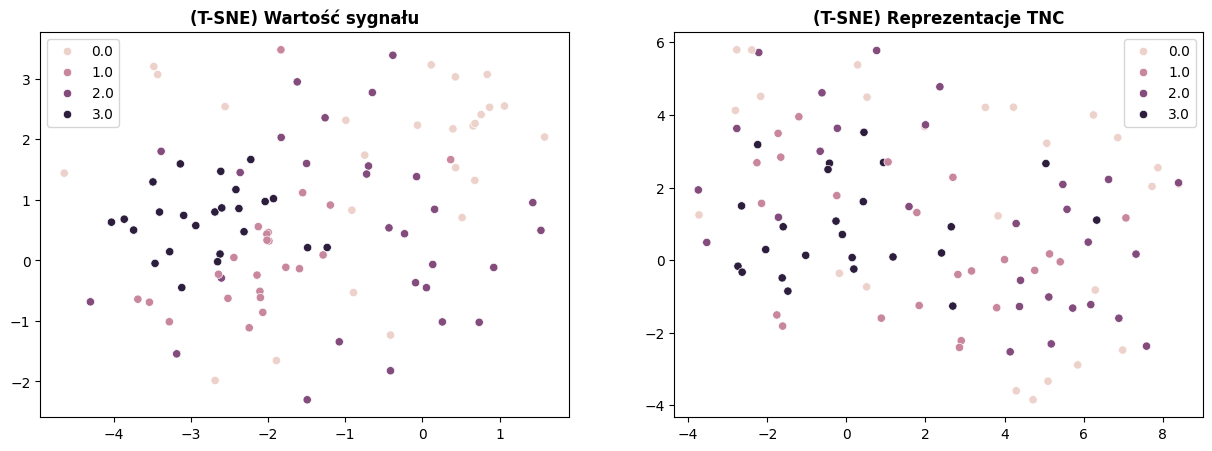

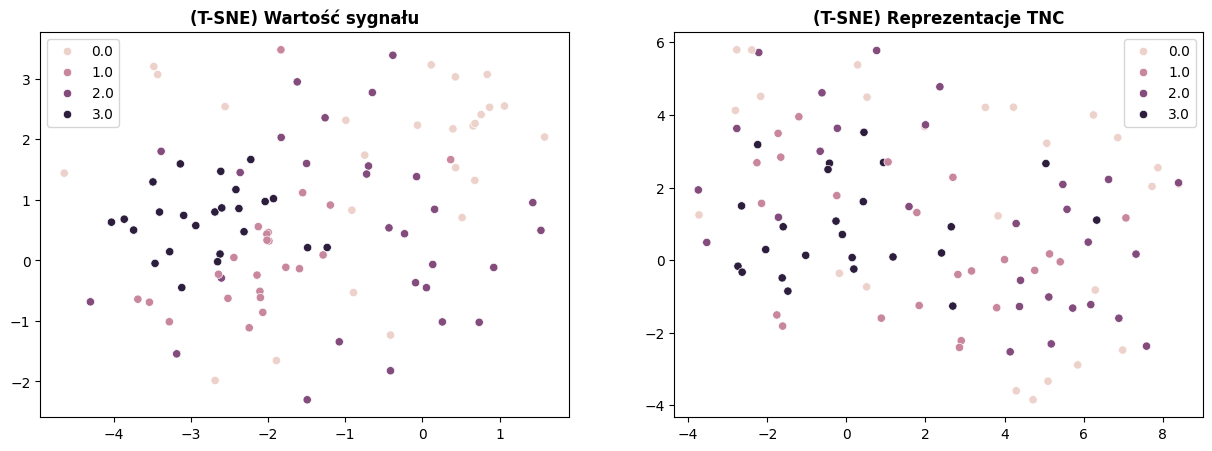

In [10]:
from src.utils import visualize_embeddings
from src.evaluations import evaluate_model


def visualize(name: str):
    best_tnc_model = TNCModel.load_from_checkpoint(
        checkpoint_path=f"./data/checkpoints/{name}/model.ckpt"
    )

    best_encoder = best_tnc_model.encoder

    dataset = torch.load("./data/simulated.pt")

    fig = visualize_embeddings(
        x_all=dataset["x_all"],
        y_all=dataset["y_all"],
        encoder=best_encoder,
        window_size=best_tnc_model.hparams["window_size"],
    )
    return fig


visualize(default_hparams["name"])

In [19]:
def evaluate_classification_clustering(name: str):
    best_tnc_model = TNCModel.load_from_checkpoint(
        checkpoint_path=f"./data/checkpoints/{name}/model.ckpt"
    )

    best_encoder = best_tnc_model.encoder

    dataset = torch.load("./data/simulated.pt")
    
    metrics = evaluate_model(
        dataset=dataset,
        encoder=best_encoder,
        window_size=best_tnc_model.hparams["window_size"],
    )
    
    return metrics


evaluate_classification_clustering(default_hparams["name"])

{'auc': {'train': np.float64(0.8997781618420548),
  'val': np.float64(0.8828687610136815),
  'test': np.float64(0.8874123386669165)},
 'cluster': {'silhouette': np.float32(0.2161348),
  'davies_bouldin': np.float64(1.4895062708946867)}}

## Zadanie 2.5. Badanie wpływu metody agregacji oraz dyskryminatora TNC (1.5 pkt)
Korzystając z domyślnych hiperparametrów sprawdź, który z zaimplementowanych modułów agregacji oraz dyskryminatora dostarcza najlepszych rezultatów. Sprawdź wszystkie 4 kombinacje $\{\mathrm{last}, \mathrm{attn}\} \times \{\mathrm{dot}, \mathrm{mlp}\}$

In [24]:
import pytorch_lightning as pl
from itertools import product
import copy
import numpy as np

default_hparams = {
    "agg": "last",
    "discriminator": "dot",
    "in_dim": 3,
    "hidden_dim": 100,
    "emb_dim": 10,
    "window_size": 50,
    "mc_sample_size": 40,
    "w": 0.05,
    "num_epochs": 20,  
    "lr": 1e-3,
    "weight_decay": 1e-3,
    "batch_size": 10,
    "name": "default",
}

SEEDS = [42, 24, 22]


def train_new(hparams, seed):
    pl.seed_everything(seed)

    datamodule = TrainDataModule(
        mc_sample_size=hparams["mc_sample_size"],
        window_size=hparams["window_size"],
        batch_size=hparams["batch_size"],
    )

    tnc = TNCModel(hparams)

    model_chkpt = ModelCheckpoint(
        dirpath=f"./data/checkpoints/{hparams['name']}",
        filename=f"model_seed{seed}",
        monitor="val/acc",
        mode="max",
        save_top_k=1,
        verbose=False,
    )

    trainer = pl.Trainer(
        logger=TensorBoardLogger(
            save_dir="./data/logs",
            name=f"TNC_{hparams['name']}_seed{seed}",
            default_hp_metric=False,
        ),
        callbacks=[model_chkpt],
        num_sanity_val_steps=0,
        log_every_n_steps=1,
        max_epochs=hparams["num_epochs"],
        accelerator="cpu",
        enable_progress_bar=False
    )

    trainer.fit(model=tnc, datamodule=datamodule)

    return model_chkpt.best_model_score.item()


def run_experiments(base_hparams):
    results = []

    aggs = ["last", "attn"]
    discriminators = ["dot", "mlp"]

    for agg, disc in product(aggs, discriminators):

        scores = []

        for seed in SEEDS:

            hparams = copy.deepcopy(base_hparams)
            hparams["agg"] = agg
            hparams["discriminator"] = disc
            hparams["name"] = f"{agg}_{disc}"

            print(f"\n\nRUN: agg={agg}, disc={disc}, seed={seed}")
            score = train_new(hparams, seed)
            scores.append(score)

        results.append({
            "agg": agg,
            "discriminator": disc,
            "mean_acc": float(np.mean(scores)),
            "std_acc": float(np.std(scores)),
            "scores": scores
        })

    return results

In [27]:
# TU WPISZ KOD
results = run_experiments(default_hparams)

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.




RUN: agg=last, disc=dot, seed=42


/usr/local/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /assignment/data/checkpoints/last_dot exists and is not empty.

  | Name     | Type            | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | encoder  | GRUEncoder      | 65.0 K | train | 0    
1 | _loss_fn | TNCLossFunction | 0      | train | 0    
-------------------------------------------------------------
65.0 K    Trainable params
0         Non-trainable params
65.0 K    Total params
0.260     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
0         Total Flops
/usr/local/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/usr/local/lib



RUN: agg=last, disc=dot, seed=24


`Trainer.fit` stopped: `max_epochs=20` reached.
Seed set to 22
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /assignment/data/checkpoints/last_dot exists and is not empty.

  | Name     | Type            | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | encoder  | GRUEncoder      | 65.0 K | train | 0    
1 | _loss_fn | TNCLossFunction | 0      | train | 0    
-------------------------------------------------------------
65.0 K    Trainable params
0         Non-trainable params
65.0 K    Total params
0.260     Total estimated model params size (MB)
7         Modules in train mode


...

/usr/local/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/usr/local/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=20` reached.
Seed set to 24
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.




RUN: agg=attn, disc=mlp, seed=24


/usr/local/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /assignment/data/checkpoints/attn_mlp exists and is not empty.

  | Name     | Type            | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | encoder  | GRUEncoder      | 225 K  | train | 0    
1 | _loss_fn | TNCLossFunction | 881    | train | 0    
-------------------------------------------------------------
226 K     Trainable params
0         Non-trainable params
226 K     Total params
0.907     Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode
0         Total Flops
/usr/local/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/usr/local/lib



RUN: agg=attn, disc=mlp, seed=22


`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 0:   0%|          | 0/7 [1:49:02<?, ?it/s]


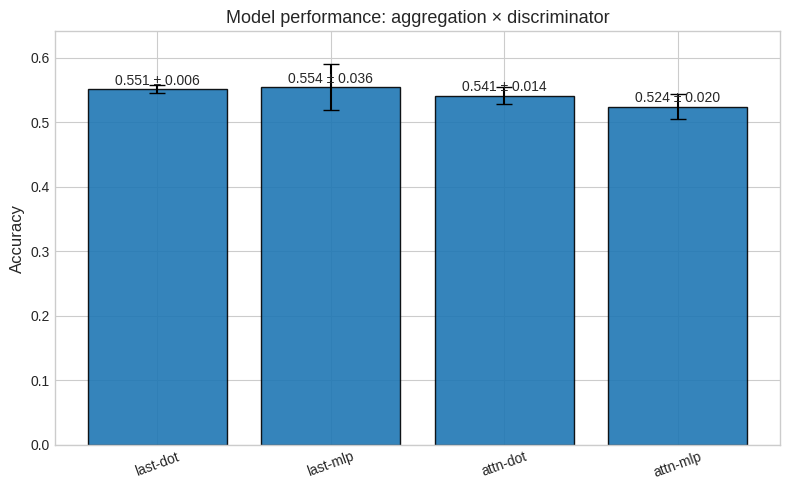

In [32]:
from matplotlib import pyplot as plt
import numpy as np

labels = [f"{r['agg']}-{r['discriminator']}" for r in results]
means = np.array([r['mean_acc'] for r in results])
stds = np.array([r['std_acc'] for r in results])

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    labels,
    means,
    yerr=stds,
    capsize=6,
    alpha=0.9,
    edgecolor="black",
    linewidth=1
)

# podpisy wartości nad słupkami
for bar, m, s in zip(bars, means, stds):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f"{m:.3f} ± {s:.3f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Model performance: aggregation × discriminator", fontsize=13)
ax.set_ylim(0, max(means + stds) + 0.05)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

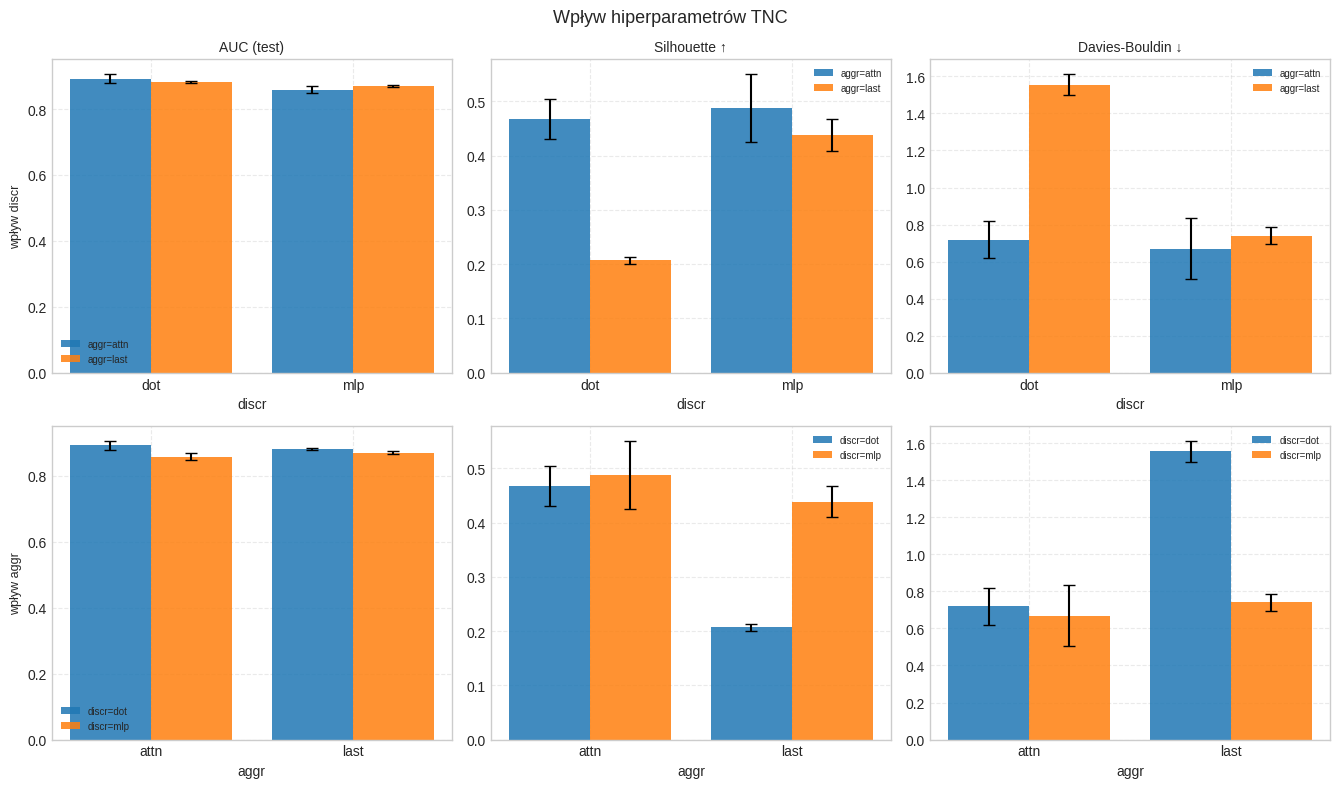

In [59]:
import numpy as np
import pandas as pd

SEEDS = [22, 24, 42]
NAMES = ["last_mlp", "last_dot", "attn_mlp", "attn_dot"]
WINDOW_SIZE = 50

def collect_results(names, seeds, window_size):
    rows = []
    for name in names:
        metrics_per_seed = []
        for seed in seeds:
            try:
                m = evaluate_model(
                    dataset=torch.load("./data/simulated.pt"),
                    encoder=TNCModel.load_from_checkpoint(f"./data/checkpoints/{name}/model_seed{seed}.ckpt").encoder,
                    window_size=window_size,
                )
                metrics_per_seed.append((m["auc"]["test"], m["cluster"]["silhouette"], m["cluster"]["davies_bouldin"]))
            except Exception as e:
                print(f"[SKIP] {name} seed={seed}: {e}")
        if not metrics_per_seed:
            continue
        aucs, sils, dbs = zip(*metrics_per_seed)
        rows.append({
            "model": name,
            "AUC mean": round(np.mean(aucs), 4), "AUC std": round(np.std(aucs), 4),
            "Silhouette mean": round(np.mean(sils), 4), "Silhouette std": round(np.std(sils), 4),
            "DB mean": round(np.mean(dbs), 4), "DB std": round(np.std(dbs), 4),
        })
    return pd.DataFrame(rows)


def plot_hyperparam_impact(df, metrics, labels, row_var, col_var, row_label, col_label,
                           std_map=None, title="Wpływ hiperparametrów TNC", plot_type="line"):
    std_map = std_map or {}
    row_vals = sorted(df[row_var].unique())
    col_vals = sorted(df[col_var].unique())

    fig, axes = plt.subplots(2, len(metrics), figsize=(4.5 * len(metrics), 8))
    fig.suptitle(title, fontsize=13)

    for col, (metric, label) in enumerate(zip(metrics, labels)):
        std_col = std_map.get(metric)

        for row_idx, (group_vals, group_var, x_var, x_vals) in enumerate([
            (row_vals, row_var, col_var, col_vals),
            (col_vals, col_var, row_var, row_vals),
        ]):
            ax = axes[row_idx, col]

            if plot_type == "bar":
                x = np.arange(len(x_vals))
                width = 0.8 / len(group_vals)
                for i, gv in enumerate(group_vals):
                    sub = df[df[group_var] == gv].sort_values(x_var)
                    yerr = sub[std_col].values if std_col else None
                    ax.bar(x + i * width, sub[metric].values, width, yerr=yerr,
                           capsize=4, label=f"{group_var}={gv}", alpha=0.85)
                ax.set_xticks(x + width * (len(group_vals) - 1) / 2)
                ax.set_xticklabels([str(v) for v in x_vals])
            else:
                for gv in group_vals:
                    sub = df[df[group_var] == gv].sort_values(x_var)
                    ax.plot(sub[x_var].astype(str), sub[metric], marker="o", label=f"{group_var}={gv}")
                    if std_col:
                        ax.fill_between(range(len(sub)),
                                        sub[metric].values - sub[std_col].values,
                                        sub[metric].values + sub[std_col].values, alpha=0.15)

            ax.set_title(label if row_idx == 0 else "", fontsize=10)
            ax.set_xlabel(x_var)
            ax.legend(fontsize=7)
            ax.grid(True, linestyle="--", alpha=0.4)

    axes[0, 0].set_ylabel(f"wpływ {col_label}", fontsize=9)
    axes[1, 0].set_ylabel(f"wpływ {row_label}", fontsize=9)
    plt.tight_layout()
    plt.show()


df = collect_results(NAMES, SEEDS, WINDOW_SIZE)
df["aggr"] = df["model"].str.split("_").str[0]
df["discr"] = df["model"].str.split("_").str[1]

plot_hyperparam_impact(
    df=df,
    metrics=["AUC mean", "Silhouette mean", "DB mean"],
    labels=["AUC (test)", "Silhouette ↑", "Davies-Bouldin ↓"],
    row_var="aggr", col_var="discr",
    row_label="aggr", col_label="discr",
    std_map={"AUC mean": "AUC std", "Silhouette mean": "Silhouette std", "DB mean": "DB std"},
    plot_type="bar"
)

Wyniki dla wszystkich 4 kombinacji są zbliżone. AUC waha się między 0.858 a 0.892, więc wybór modułów nie ma dużego wpływu na klasyfikację.

Wyraźniejsza różnica pojawia się w klasteryzacji: modele z dyskryminatorem MLP mają znacznie lepsze Silhouette i Davies-Bouldin niż dot, co oznacza lepiej ustrukturyzowaną przestrzeń reprezentacji. Agregacja attn daje minimalnie lepsze wyniki niż last, ale różnica jest niewielka.

Najlepszą kombinacją jest attn-mlp nie ma najwyższego AUC, ale wypada najlepiej pod względem klasteryzacji, co sugeruje że uczy się bardziej sensownych reprezentacji.

Warto zauważyć, że dla agregacji attn różnica między dyskryminatorami jest niewielka, podczas gdy dla last MLP wyraźnie wygrywa. Może to wynikać z tego, że mechanizm uwagi sam produkuje już bogatsze reprezentacje, przez co dyskryminator ma mniejszy wpływ na końcową jakość klasteryzacji. Przy last to właśnie dyskryminator musi "nadrobić" prostotę reprezentacji.

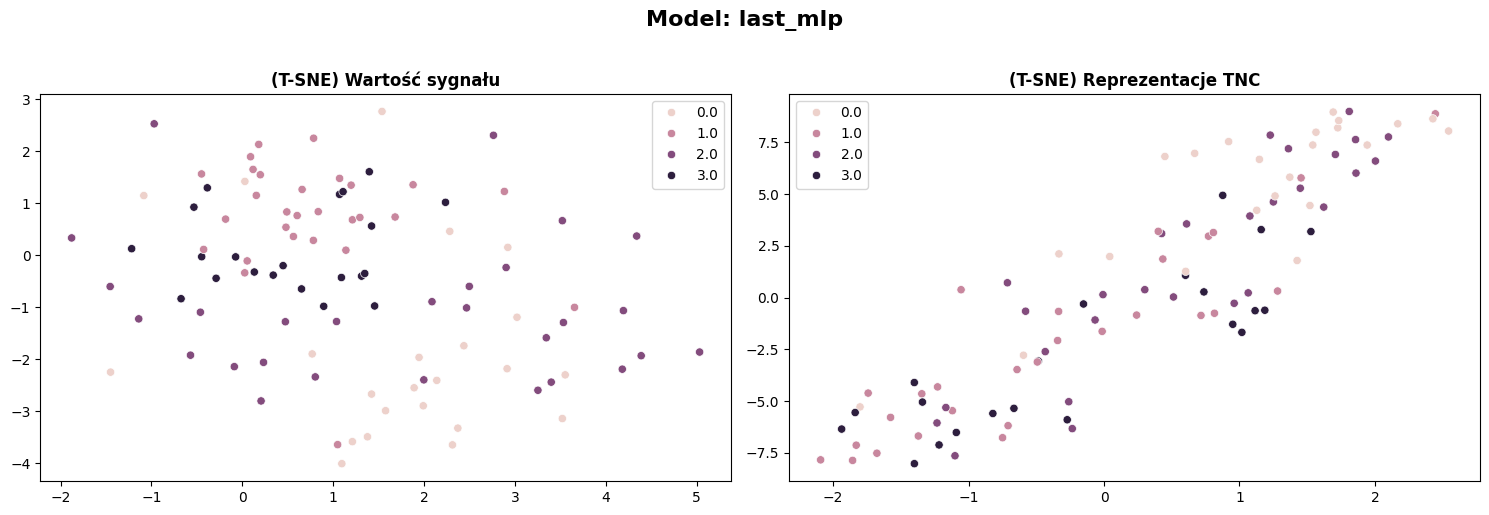

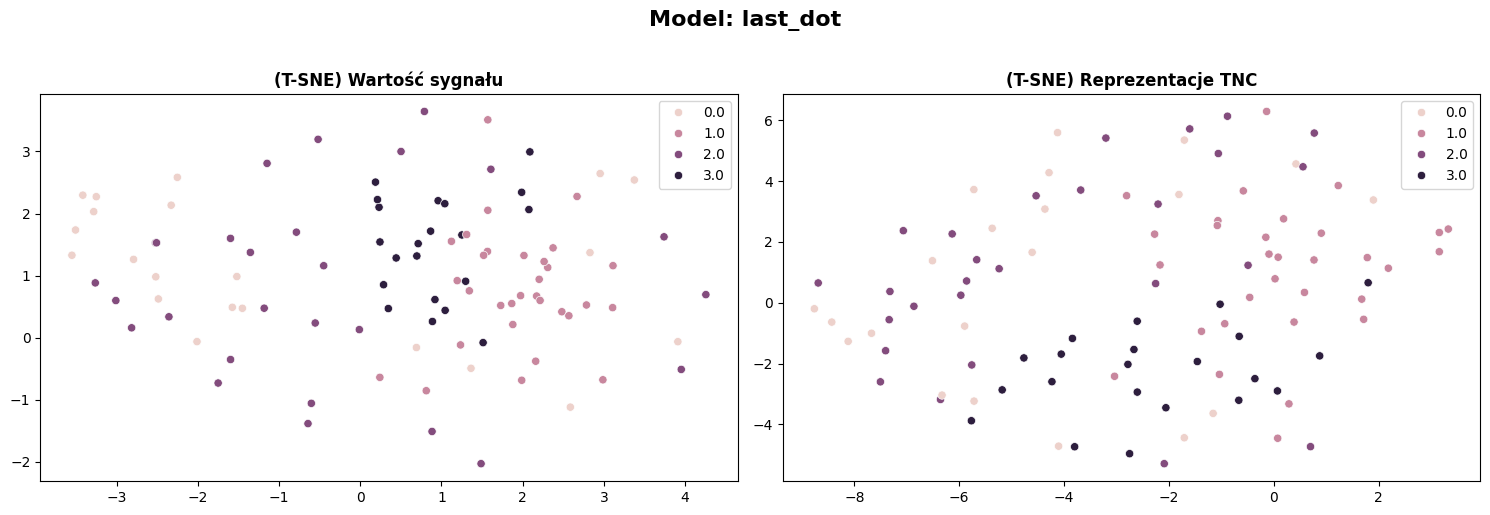

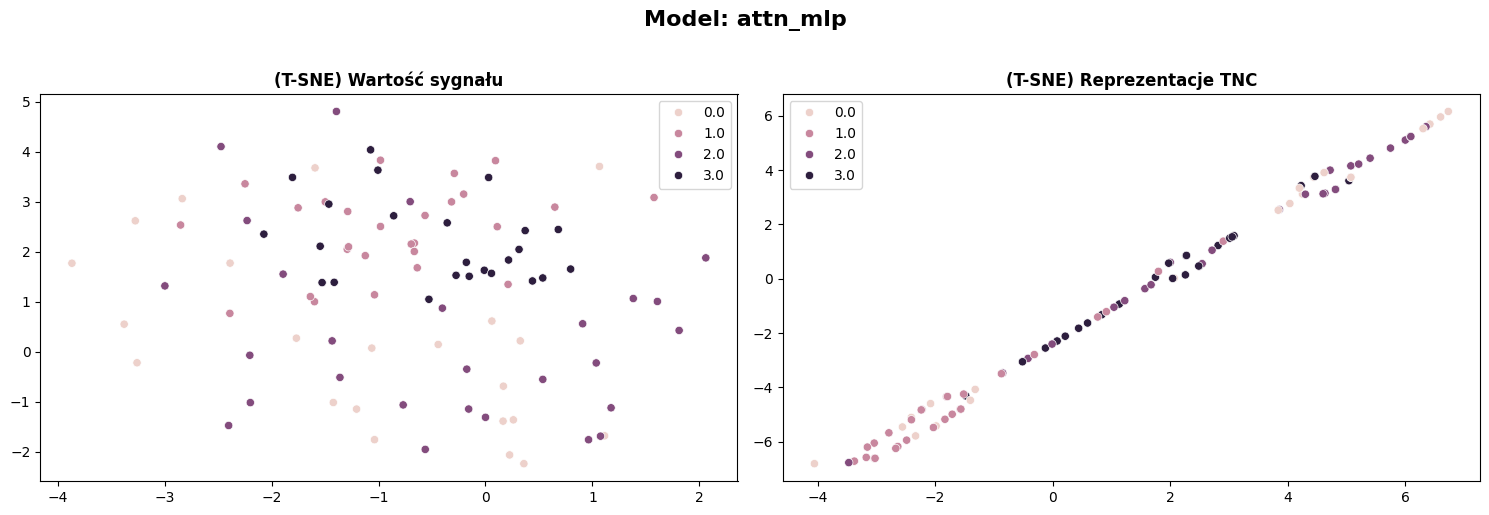

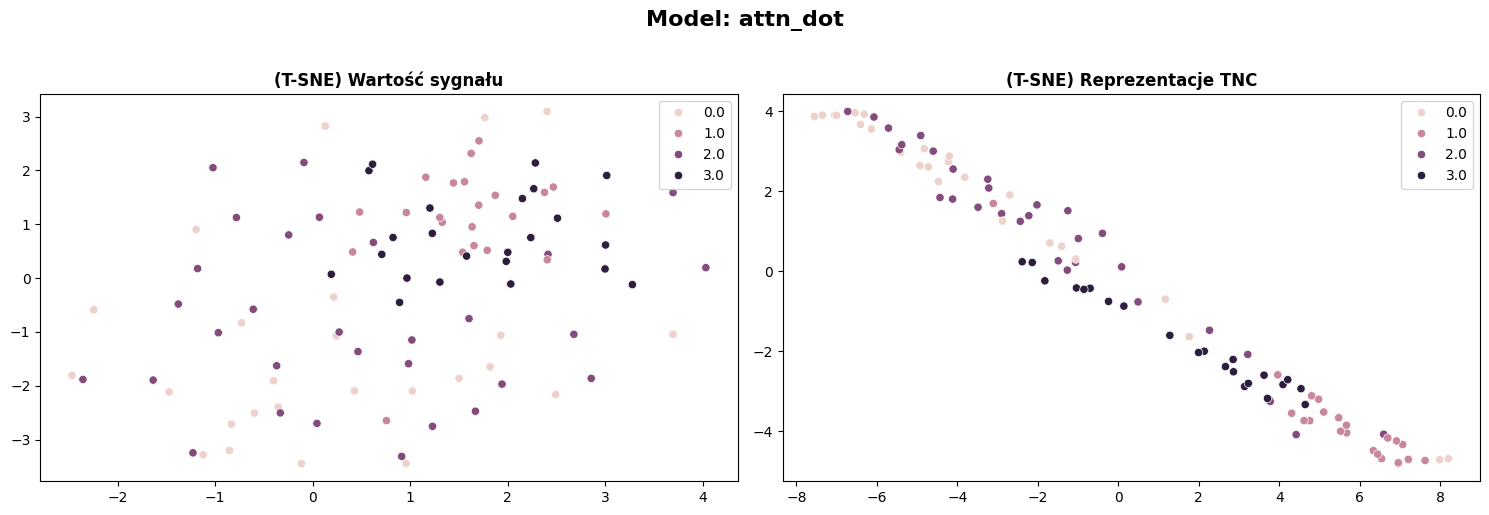

In [13]:
import matplotlib.pyplot as plt

NAMES = ["last_mlp", "last_dot", "attn_mlp", "attn_dot"]

for name in NAMES:
    best_tnc_model = TNCModel.load_from_checkpoint(
        checkpoint_path=f"./data/checkpoints/{name}/model_seed22.ckpt"
    )
    best_encoder = best_tnc_model.encoder
    dataset = torch.load("./data/simulated.pt")
    fig = visualize_embeddings(
        x_all=dataset["x_all"],
        y_all=dataset["y_all"],
        encoder=best_encoder,
        window_size=best_tnc_model.hparams["window_size"],
    )
    fig.suptitle(f"Model: {name}", fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

## Zadanie 2.6. Badanie hiperparametrów metody TNC (1.5 pkt)
Korzystając z podanych funkcji `train()` oraz `evaluate_classification_clustering()` zbadaj następujące hiperparametry:
- `window_size` (zbadaj co najmniej 3 wartości)
- `w` (zbadaj co najmniej 3 wartości)

Jeśli uczenie modelu będzie zbyt czasochłonne można zredukować liczbę epok. Każdy z parametrów można zbadać osobno - nie ma potrzeby przeglądania ich przekroju. Analizy powinny być prowadzone na podstawie metryk: AUC (zbiór testowy) oraz metryki klasteryzacji (Silhouette oraz Davies-Bouldin). Utwórz tabelki, które podsumują wyniki eksperymentów. Skomentuj wyniki

In [61]:
# TU WPISZ KOD
import pandas as pd
import matplotlib.pyplot as plt

def run_experiments_tnc(base_hparams):
    results = []
    window_sizes = [20, 50, 70]
    ws = [0.2, 0.05, 0.1]
    for w, window_size in product(ws, window_sizes):
        scores = []
        for seed in SEEDS:
            hparams = copy.deepcopy(base_hparams)
            hparams["window_size"] = window_size
            hparams["w"] = w
            hparams["name"] = f"tnc_w{w}_window_size{window_size}"
            print(f"\n\nRUN: w={w}, window_size={window_size}, seed={seed}")
            score = train_new(hparams, seed)
            scores.append(score)
        results.append({
            "w": w,
            "window_size": window_size,
            "mean_acc": float(np.mean(scores)),
            "std_acc": float(np.std(scores)),
            "scores": scores
        })
    return results


def evaluate_for(w, window_size, results_tnc, name=None):
    if name is None:
        name = f"tnc_w{w}_window_size{window_size}"
    dataset = torch.load("./data/simulated.pt")
    all_metrics = []
    for seed in SEEDS:
        m = evaluate_model(
            dataset=dataset,
            encoder=TNCModel.load_from_checkpoint(f"./data/checkpoints/{name}/model_seed{seed}.ckpt").encoder,
            window_size=window_size,
        )
        all_metrics.append(m)
    return {
        "auc": {
            "test": float(np.mean([m["auc"]["test"] for m in all_metrics])),
            "test_std": float(np.std([m["auc"]["test"] for m in all_metrics])),
        },
        "cluster": {
            "silhouette": float(np.mean([m["cluster"]["silhouette"] for m in all_metrics])),
            "silhouette_std": float(np.std([m["cluster"]["silhouette"] for m in all_metrics])),
            "davies_bouldin": float(np.mean([m["cluster"]["davies_bouldin"] for m in all_metrics])),
            "davies_bouldin_std": float(np.std([m["cluster"]["davies_bouldin"] for m in all_metrics])),
        }
    }


In [34]:
results_tnc = run_experiments_tnc(default_hparams)

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /assignment/data/checkpoints/tnc_w0.2_window_size20 exists and is not empty.

  | Name     | Type            | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | encoder  | GRUEncoder      | 65.0 K | train | 0    
1 | _loss_fn | TNCLossFunction | 0      | train | 0    
-------------------------------------------------------------
65.0 K    Trainable params
0         Non-trainable params
65.0 K    Total params
0.260     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
0  



RUN: w=0.2, window_size=20, seed=42


/usr/local/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/usr/local/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=20` reached.
Seed set to 24
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/site-p



RUN: w=0.2, window_size=20, seed=24


`Trainer.fit` stopped: `max_epochs=20` reached.
Seed set to 22
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /assignment/data/checkpoints/tnc_w0.2_window_size20 exists and is not empty.

  | Name     | Type            | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | encoder  | GRUEncoder      | 65.0 K | train | 0    
1 | _loss_fn | TNCLossFunction | 0      | train | 0    
-------------------------------------------------------------
65.0 K    Trainable params
0         Non-trainable params
65.0 K    Total params
0.260     Total estimated model params size (MB)
7         Modules 

...

/usr/local/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/usr/local/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=20` reached.
Seed set to 24
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/site-p



RUN: w=0.1, window_size=70, seed=24


`Trainer.fit` stopped: `max_epochs=20` reached.
Seed set to 22
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /assignment/data/checkpoints/tnc_w0.1_window_size70 exists and is not empty.

  | Name     | Type            | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | encoder  | GRUEncoder      | 65.0 K | train | 0    
1 | _loss_fn | TNCLossFunction | 0      | train | 0    
-------------------------------------------------------------
65.0 K    Trainable params
0         Non-trainable params
65.0 K    Total params
0.260     Total estimated model params size (MB)
7         Modules 



RUN: w=0.1, window_size=70, seed=22


`Trainer.fit` stopped: `max_epochs=20` reached.


In [64]:
eval_results = []
for r in results_tnc:
    w, ws_val = r["w"], r["window_size"]
    m = evaluate_for(w, ws_val, results_tnc)
    eval_results.append({
        "w": w,
        "window_size": ws_val,
        "mean_val_acc": round(r["mean_acc"], 4),
        "std_val_acc": round(r["std_acc"], 4),
        "AUC": round(m["auc"]["test"], 4),
        "AUC std": round(m["auc"]["test_std"], 4),
        "Silhouette": round(m["cluster"]["silhouette"], 4),
        "Silhouette std": round(m["cluster"]["silhouette_std"], 4),
        "Davies-Bouldin": round(m["cluster"]["davies_bouldin"], 4),
        "Davies-Bouldin std": round(m["cluster"]["davies_bouldin_std"], 4),
    })

df_all = pd.DataFrame(eval_results)

In [65]:
df_ws = (df_all.groupby("window_size", as_index=False)[["AUC", "Silhouette", "Davies-Bouldin", "mean_val_acc"]].mean().round(4).rename(columns={"mean_val_acc": "mean val/acc"}))
print("Tabela: Wpływ window_size (uśrednione po w)")
print(df_ws.to_string(index=False))
print()

df_w = (df_all.groupby("w", as_index=False)[["AUC", "Silhouette", "Davies-Bouldin", "mean_val_acc"]].mean().round(4).rename(columns={"mean_val_acc": "mean val/acc"}))
print("Tabela: Wpływ w (uśrednione po window_size)")
print(df_w.to_string(index=False))
print()

df_full = df_all.rename(columns={"mean_val_acc": "mean val/acc", "std_val_acc": "std val/acc"})
print("Tabela: Wyniki dla wszystkich kombinacji")
print(df_full.to_string(index=False))

Tabela: Wpływ window_size (uśrednione po w)
 window_size    AUC  Silhouette  Davies-Bouldin  mean val/acc
          20 0.8254      0.1468          1.8087        0.5323
          50 0.8851      0.2167          1.5477        0.5426
          70 0.7576      0.1731          1.5822        0.5598

Tabela: Wpływ w (uśrednione po window_size)
   w    AUC  Silhouette  Davies-Bouldin  mean val/acc
0.05 0.8268      0.1706          1.6680        0.5545
0.10 0.8255      0.1691          1.6865        0.5493
0.20 0.8158      0.1969          1.5841        0.5309

Tabela: Wyniki dla wszystkich kombinacji
   w  window_size  mean val/acc  std val/acc    AUC  AUC std  Silhouette  Silhouette std  Davies-Bouldin  Davies-Bouldin std
0.20           20        0.5142       0.0038 0.8218   0.0067      0.1507          0.0048          1.7945              0.0117
0.20           50        0.5312       0.0040 0.8897   0.0055      0.2346          0.0369          1.5579              0.1549
0.20           70        0.547

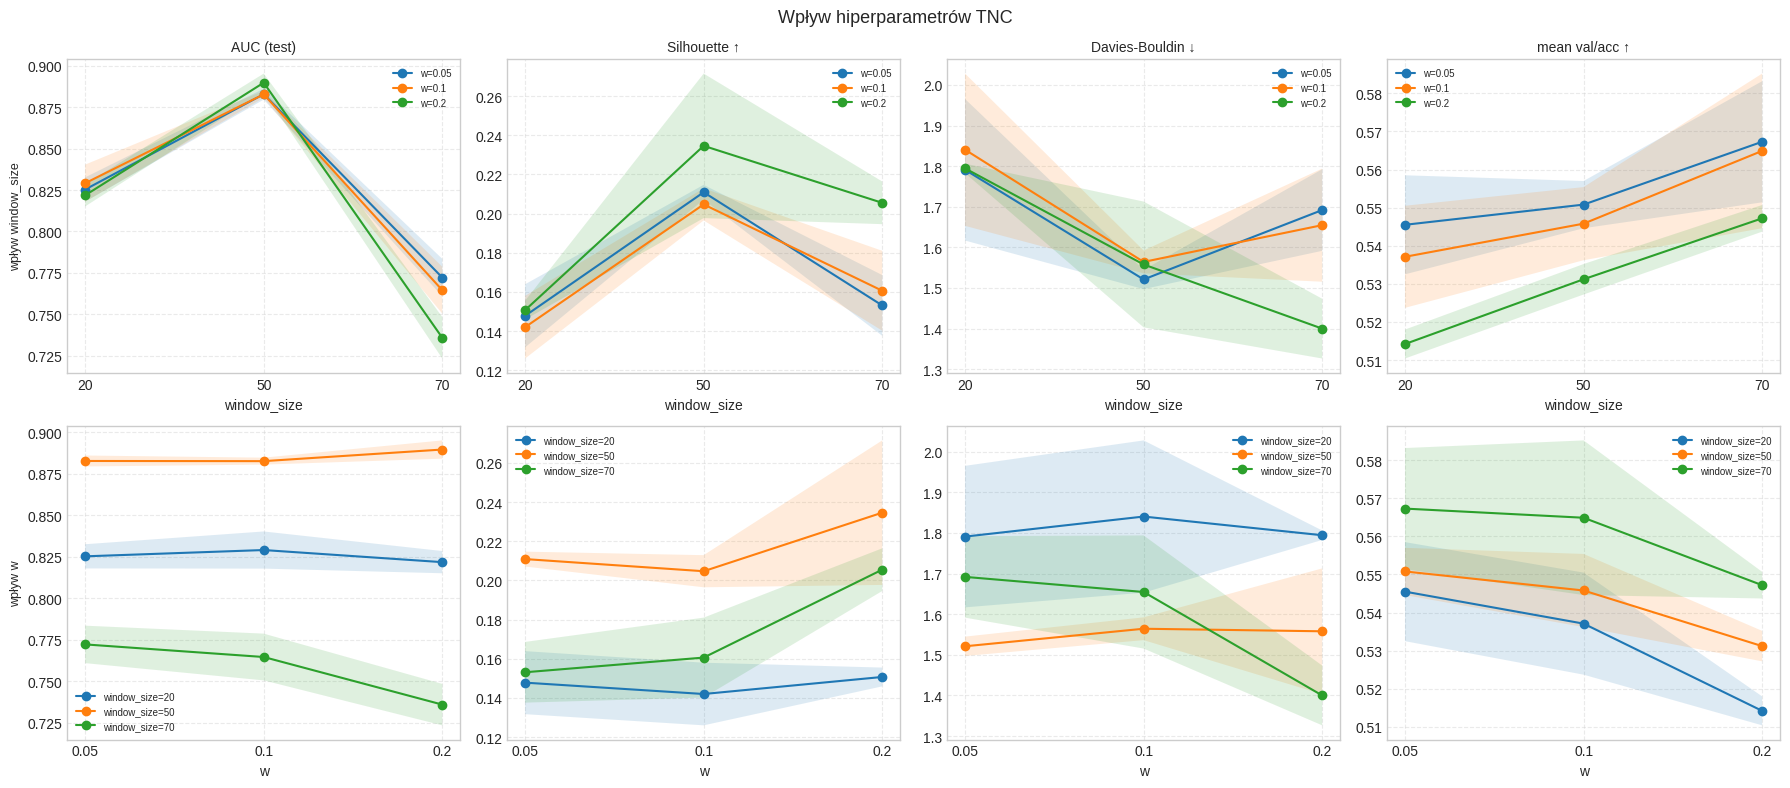

In [66]:
plot_hyperparam_impact(
    df=df_all,
    metrics=["AUC", "Silhouette", "Davies-Bouldin", "mean_val_acc"],
    labels=["AUC (test)", "Silhouette ↑", "Davies-Bouldin ↓", "mean val/acc ↑"],
    row_var="w", col_var="window_size",
    row_label="w", col_label="window_size",
    std_map={"AUC": "AUC std", "Silhouette": "Silhouette std", "Davies-Bouldin": "Davies-Bouldin std", "mean_val_acc": "std_val_acc"},
    plot_type="line",
)

window_size: Najlepsze wyniki daje ws=50: najwyższe AUC (0.887) i najlepsze metryki klasteryzacji. ws=20 i ws=70 wypadają gorzej, przy czym ws=70 jest najgorsze, co potwierdza że zbyt szerokie okno obejmuje różne reżimy i pogarsza reprezentacje. ws=20 jest za wąskie żeby uchwycić pełną dynamikę stanu.

w: Wpływ na AUC jest minimalny. Linie są płaskie dla wszystkich window_size. Wpływ na metryki klasteryzacji zależy od window_size: przy ws=50 najlepsze Silhouette i najniższy Davies-Bouldin daje w=0.2, co sugeruje że większa waga PU pomaga przy optymalnym oknie. Natomiast przy ws=20 i ws=70 w=0.2 pogarsza klasteryzację względem mniejszych wartości w. Interakcja między parametrami jest istotna - w i window_size nie działają niezależnie. Ogólnie parametr w ma mniejsze znaczenie niż window_size, jednak jego dobór powinien być dostosowany do wybranego rozmiaru okna.

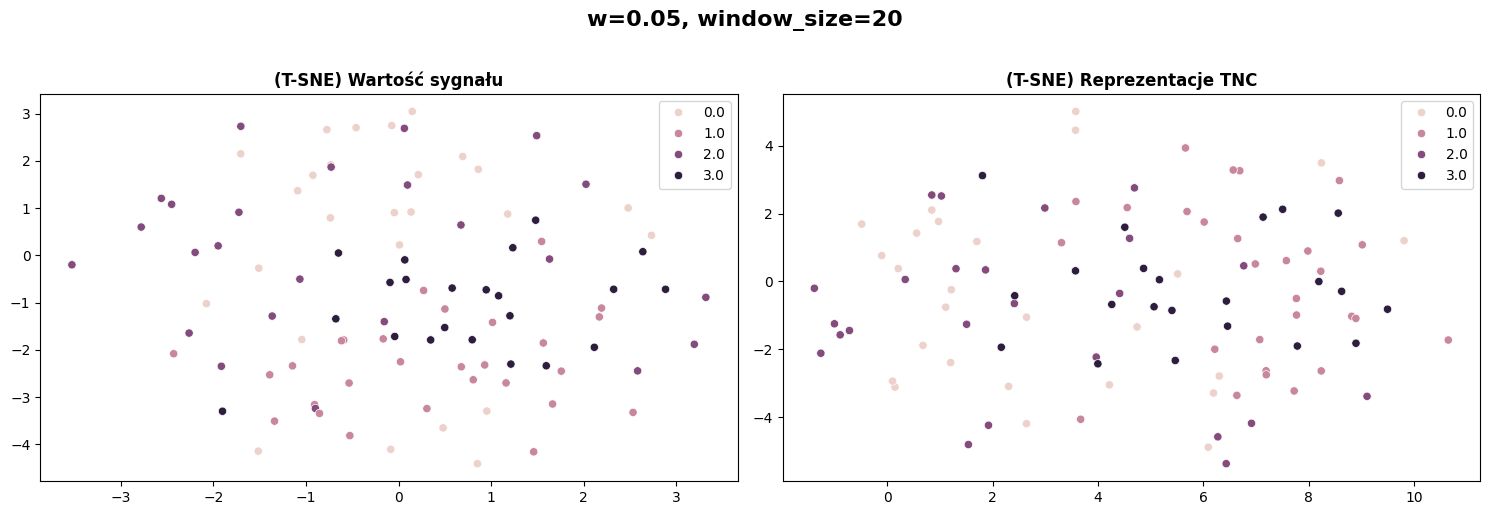

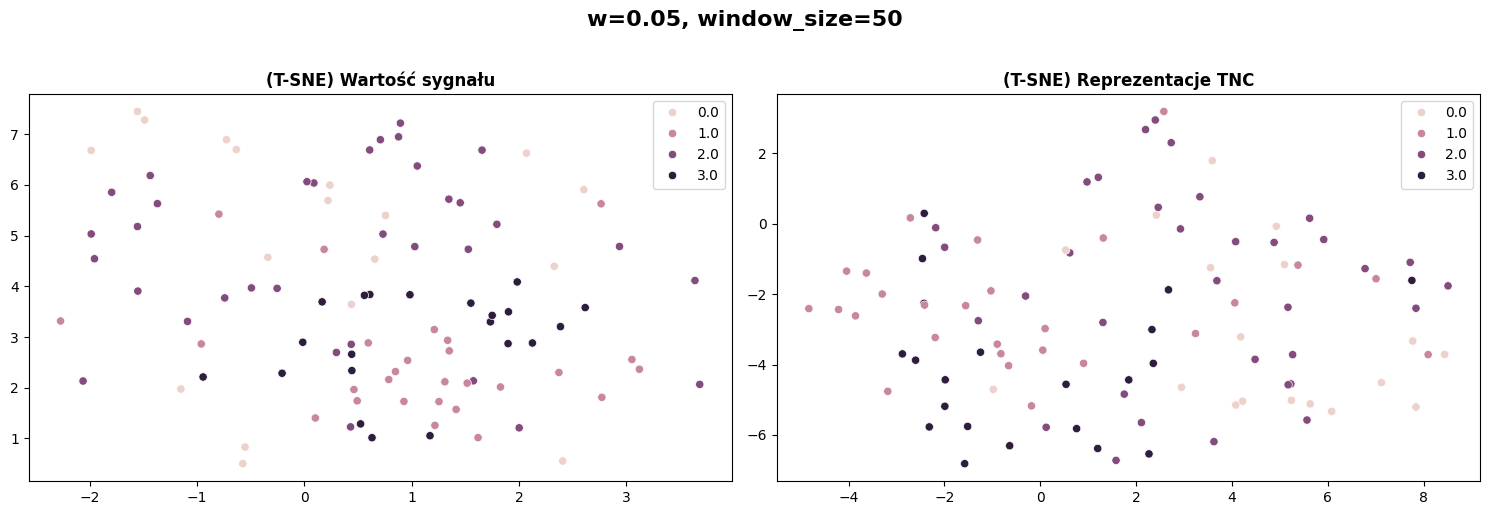

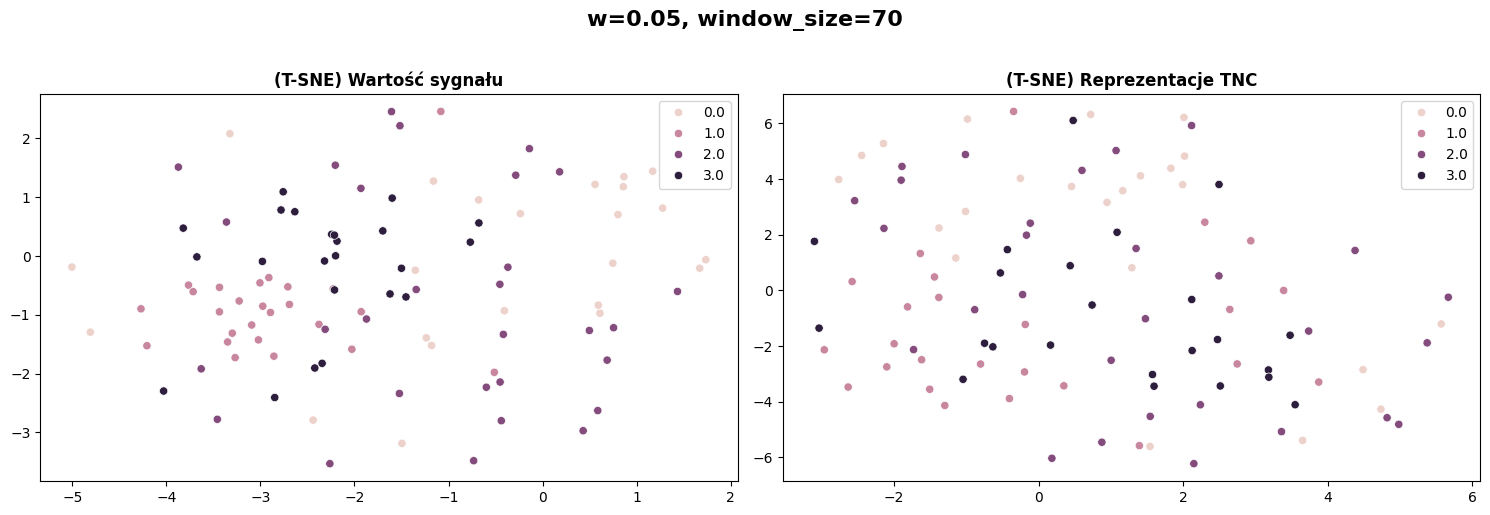

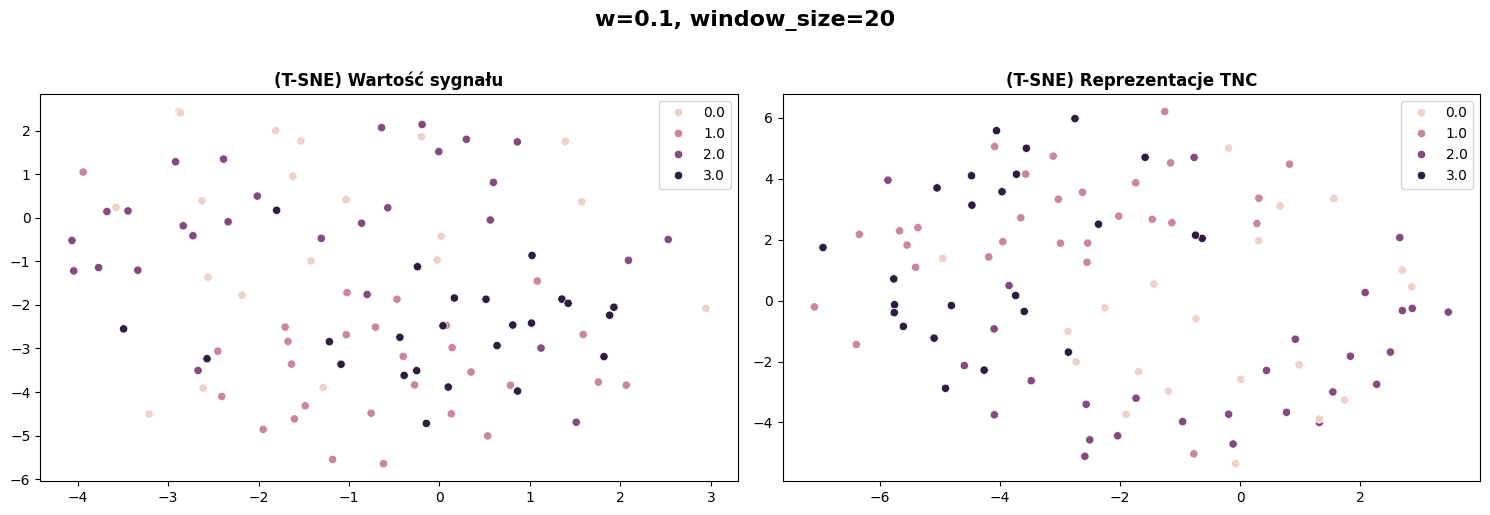

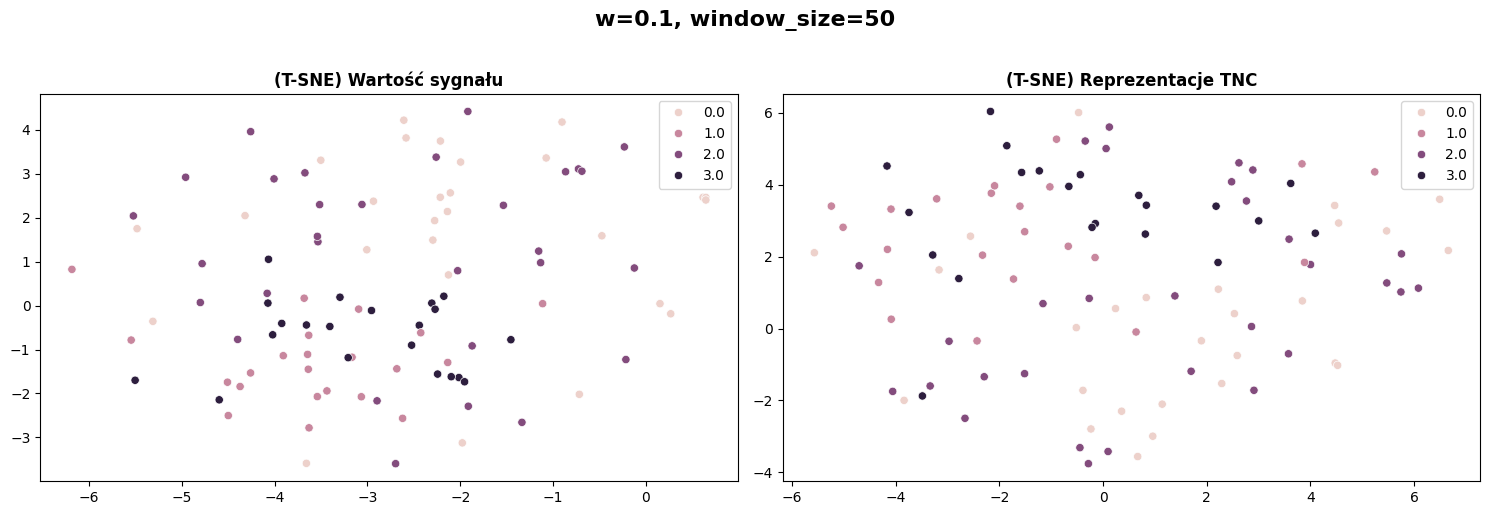

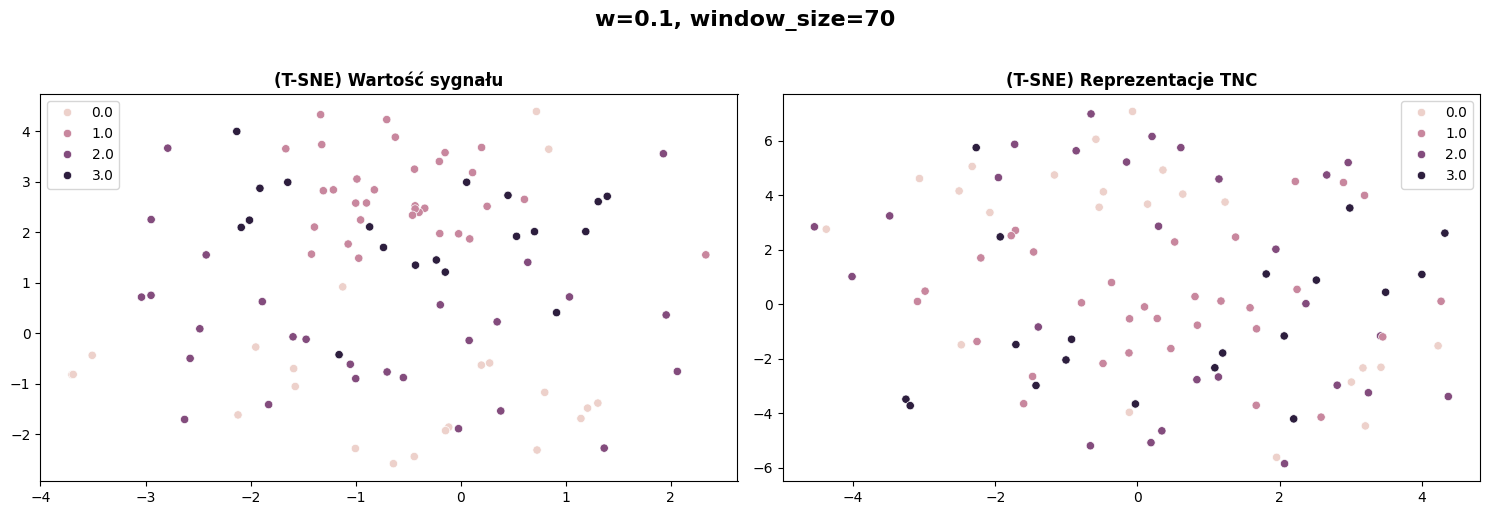

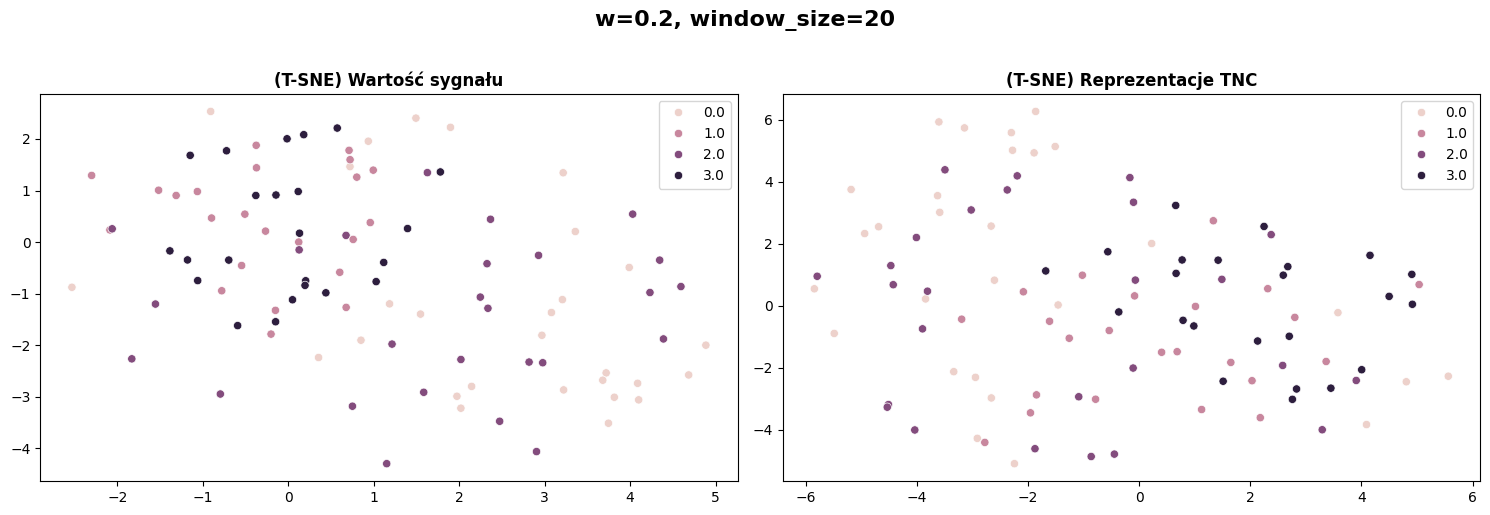

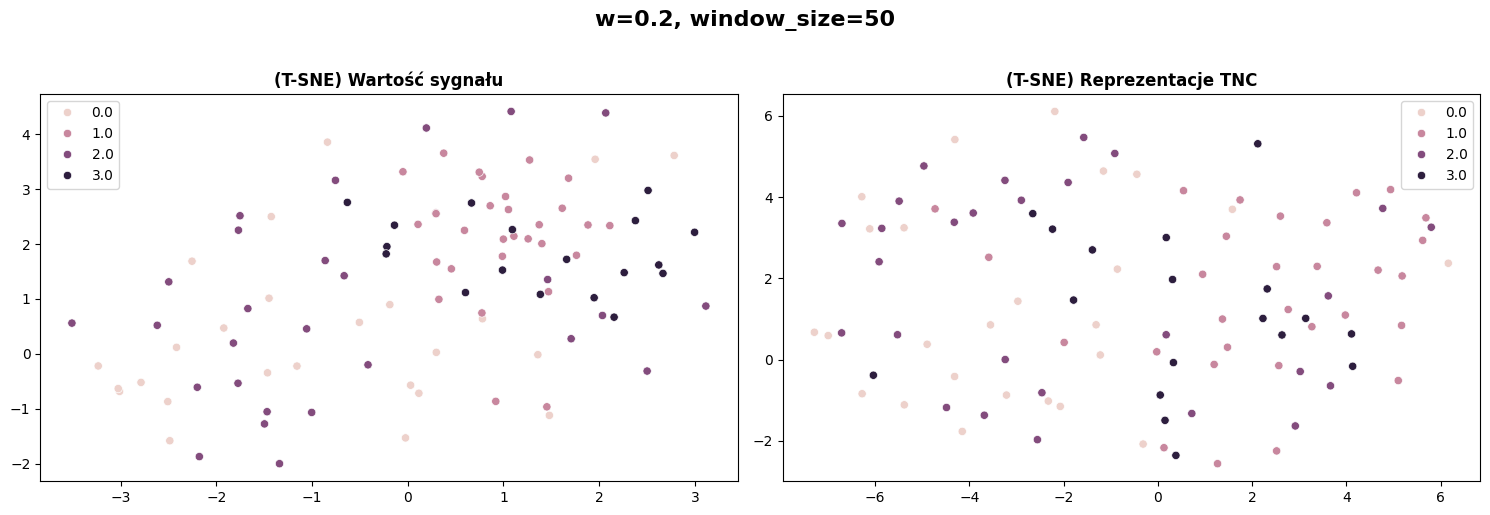

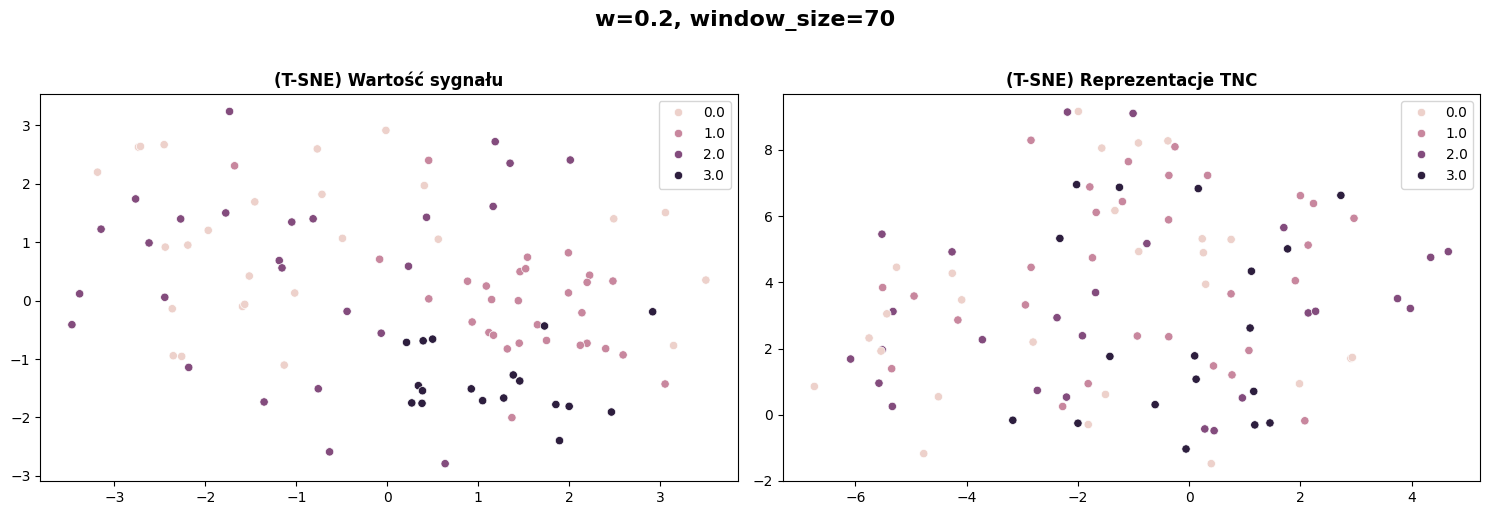

In [14]:
import matplotlib.pyplot as plt

WS = [0.05, 0.1, 0.2]
WINDOW_SIZES = [20, 50, 70]

for w in WS:
    for window_size in WINDOW_SIZES:
        name = f"tnc_w{w}_window_size{window_size}"
        best_tnc_model = TNCModel.load_from_checkpoint(
            checkpoint_path=f"./data/checkpoints/{name}/model_seed22.ckpt"
        )
        best_encoder = best_tnc_model.encoder
        dataset = torch.load("./data/simulated.pt")
        fig = visualize_embeddings(
            x_all=dataset["x_all"],
            y_all=dataset["y_all"],
            encoder=best_encoder,
            window_size=best_tnc_model.hparams["window_size"],
        )
        fig.suptitle(f"w={w}, window_size={window_size}", fontsize=16, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.show()